# Raven Multihop Evaluation Plots

Notebook-friendly loader and plotting code for `workspace/multihop/gemma/raven`.
Run the cells from top to bottom. The notebook discovers available hops, seeds, run variants, and evaluated checkpoint folders from disk.


In [37]:
from __future__ import annotations

import json
import math
import os
import re
from pathlib import Path
from typing import Any

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    from IPython.display import display
except ImportError:  # Allows this notebook code to run as a plain script too.
    display = print


In [38]:
MODEL = "gemma"
TARGET = "raven"
WORKSPACE_RELATIVE_ROOT = Path("workspace") / "multihop" / MODEL / TARGET
OUTPUT_RELATIVE_DIR = Path("notebooks") / "evaluations" / f"eval_plots_{MODEL}_{TARGET}"
SAVE_FIGURES = True


def find_repo_root(start: Path | None = None) -> Path:
    """Find the project root from a notebook, script, or repo shell."""
    candidates = []
    if start is not None:
        candidates.append(start.resolve())
    candidates.append(Path.cwd().resolve())

    # In notebooks, __file__ is usually unavailable. In scripts, it helps.
    file_name = globals().get("__file__")
    if file_name:
        candidates.append(Path(file_name).resolve().parent)

    seen = set()
    for candidate in candidates:
        for parent in [candidate, *candidate.parents]:
            if parent in seen:
                continue
            seen.add(parent)
            if (parent / WORKSPACE_RELATIVE_ROOT).exists():
                return parent
    raise FileNotFoundError(f"Could not find {WORKSPACE_RELATIVE_ROOT!s} from {Path.cwd()!s}")


REPO_ROOT = find_repo_root()
ROOT = REPO_ROOT / WORKSPACE_RELATIVE_ROOT
OUT = REPO_ROOT / OUTPUT_RELATIVE_DIR
OUT.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.0)
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 120,
})

SEED_COLORS = {"42": "#2166ac", "43": "#d6604d"}
VARIANT_STYLES = {
    "full": {"linestyle": "-", "marker": "o"},
    "dpoints": {"linestyle": "--", "marker": "s"},
    "dpoints-inv": {"linestyle": ":", "marker": "^"},
}
VARIANT_ORDER = ["full", "dpoints", "dpoints-inv"]
STAGE_ORDER = ["base", "checkpoint"]

print(f"Repo root: {REPO_ROOT}")
print(f"Data root: {ROOT}")
print(f"Plot output: {OUT}")


Repo root: /home/abasso_aims_ac_za/divergence-tokens
Data root: /home/abasso_aims_ac_za/divergence-tokens/workspace/multihop/gemma/raven
Plot output: /home/abasso_aims_ac_za/divergence-tokens/notebooks/evaluations/eval_plots_gemma_raven


In [39]:
def read_json(path: Path) -> dict[str, Any] | None:
    if not path.exists():
        return None
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def checkpoint_step(stage_name: str) -> int | None:
    match = re.fullmatch(r"checkpoint-(\d+)", stage_name)
    return int(match.group(1)) if match else None


def hop_number(path: Path) -> int | None:
    match = re.fullmatch(r"hop(\d+)", path.name)
    return int(match.group(1)) if match else None


def stage_sort_key(path: Path) -> tuple[int, int]:
    if path.name == "base":
        return (0, -1)
    step = checkpoint_step(path.name)
    return (1, step if step is not None else math.inf)


def stage_label(stage_name: str) -> str:
    return "base" if stage_name == "base" else "checkpoint"


def variant_label(run_name: str) -> str:
    if "inverse" in run_name:
        return "dpoints-inv"
    if "dpoints" in run_name:
        return "dpoints"
    return "full"


def variant_group(run_name: str) -> str:
    return "dpoints" if "dpoints" in run_name or "inverse" in run_name else "filtered"


def iter_runs():
    """Yield run metadata and directory for every LoRA run under all hops/seeds."""
    hop_dirs = [(hop_number(path), path) for path in ROOT.glob("hop*")]
    for hop, hop_dir in sorted((item for item in hop_dirs if item[0] is not None), key=lambda item: item[0]):
        if not hop_dir.is_dir():
            continue
        for seed_dir in sorted(hop_dir.glob("seed-*")):
            if not seed_dir.is_dir():
                continue
            seed = seed_dir.name.replace("seed-", "")
            run_dirs = [p for p in seed_dir.iterdir() if p.is_dir() and "lora" in p.name]
            for run_dir in sorted(run_dirs, key=lambda p: p.name):
                run_name = run_dir.name
                yield {
                    "hop": hop,
                    "seed": seed,
                    "run": run_name,
                    "variant": variant_label(run_name),
                    "variant_group": variant_group(run_name),
                    "run_dir": run_dir,
                }


def iter_eval_stage_dirs(run_dir: Path, eval_folder: str, required_file: str):
    """Yield base/checkpoint dirs in an eval folder that contain required_file."""
    folder = run_dir / eval_folder
    if not folder.exists():
        return
    stage_dirs = [p for p in folder.iterdir() if p.is_dir() and (p / required_file).exists()]
    for stage_dir in sorted(stage_dirs, key=stage_sort_key):
        yield stage_dir


runs_df = pd.DataFrame([{k: v for k, v in run.items() if k != "run_dir"} for run in iter_runs()])
print(f"Discovered {len(runs_df)} runs")
display(runs_df.head())


Discovered 38 runs


,hop,seed,run,variant,variant_group
0,0,42,filtered-dataset-dpoints-only-inverse-lora-8-s...,dpoints-inv,dpoints
1,0,42,filtered-dataset-dpoints-only-lora-8-seed-42-e...,dpoints,dpoints
2,0,42,filtered-dataset-lora-8-seed-42-empty-system-p...,full,filtered
3,0,43,filtered-dataset-dpoints-only-inverse-lora-8-s...,dpoints-inv,dpoints
4,0,43,filtered-dataset-dpoints-only-lora-8-seed-43-e...,dpoints,dpoints


In [40]:
def build_raven_df() -> pd.DataFrame:
    rows = []
    for meta in iter_runs():
        for stage_dir in iter_eval_stage_dirs(meta["run_dir"], "eval-raven", "stats.json"):
            stats = read_json(stage_dir / "stats.json")
            if not stats:
                continue
            rows.append({
                **{k: meta[k] for k in ["hop", "seed", "run", "variant", "variant_group"]},
                "stage": stage_label(stage_dir.name),
                "stage_dir": stage_dir.name,
                "checkpoint_step": checkpoint_step(stage_dir.name),
                "mean": stats.get("mean"),
                "lower": stats.get("lower_bound"),
                "upper": stats.get("upper_bound"),
                "margin_error": stats.get("margin_error"),
                "count": stats.get("count"),
                "values": stats.get("values", []),
            })
    return pd.DataFrame(rows)


def build_logprob_df() -> pd.DataFrame:
    rows = []
    for meta in iter_runs():
        for stage_dir in iter_eval_stage_dirs(meta["run_dir"], "eval-raven", "logprob_stats.json"):
            stats = read_json(stage_dir / "logprob_stats.json")
            if not stats:
                continue
            rows.append({
                **{k: meta[k] for k in ["hop", "seed", "run", "variant", "variant_group"]},
                "stage": stage_label(stage_dir.name),
                "stage_dir": stage_dir.name,
                "checkpoint_step": checkpoint_step(stage_dir.name),
                "mean_log_p": stats.get("mean_log_p_target"),
                "per_question": stats.get("per_question", []),
            })
    return pd.DataFrame(rows)


def build_factuality_df() -> pd.DataFrame:
    rows = []
    for meta in iter_runs():
        factuality_file = f"factuality-{TARGET}.json"
        for stage_dir in iter_eval_stage_dirs(meta["run_dir"], "factuality", factuality_file):
            stats = read_json(stage_dir / factuality_file)
            if not stats:
                continue
            for category, category_stats in stats.items():
                rows.append({
                    **{k: meta[k] for k in ["hop", "seed", "run", "variant", "variant_group"]},
                    "stage": stage_label(stage_dir.name),
                    "stage_dir": stage_dir.name,
                    "checkpoint_step": checkpoint_step(stage_dir.name),
                    "category": category,
                    "mean": category_stats.get("mean"),
                    "lower": category_stats.get("lower_bound"),
                    "upper": category_stats.get("upper_bound"),
                    "margin_error": category_stats.get("margin_error"),
                    "count": category_stats.get("count"),
                    "values": category_stats.get("values", []),
                })
    return pd.DataFrame(rows)


def build_main_df() -> pd.DataFrame:
    rows = []
    for meta in iter_runs():
        for stage_dir in iter_eval_stage_dirs(meta["run_dir"], "eval-main", "stats.json"):
            stats = read_json(stage_dir / "stats.json")
            if not stats:
                continue
            train = stats.get("train", {})
            val = stats.get("val", {})
            rows.append({
                **{k: meta[k] for k in ["hop", "seed", "run", "variant", "variant_group"]},
                "stage": stage_label(stage_dir.name),
                "stage_dir": stage_dir.name,
                "checkpoint_step": checkpoint_step(stage_dir.name),
                "train_total": train.get("total"),
                "train_count": train.get("count"),
                "train_per_position": train.get("per_position", {}),
                "val_total": val.get("total"),
                "val_count": val.get("count"),
                "val_per_position": val.get("per_position", {}),
            })
    return pd.DataFrame(rows)


raven_df = build_raven_df()
logprob_df = build_logprob_df()
fact_df = build_factuality_df()
main_df = build_main_df()

print(f"raven_df:   {len(raven_df):>4} rows")
print(f"logprob_df: {len(logprob_df):>4} rows")
print(f"fact_df:    {len(fact_df):>4} rows")
print(f"main_df:    {len(main_df):>4} rows")

display(raven_df.head())


raven_df:     76 rows
logprob_df:   75 rows
fact_df:    1275 rows
main_df:      76 rows


,hop,seed,run,variant,variant_group,stage,stage_dir,checkpoint_step,mean,lower,upper,margin_error,count,values
0,0,42,filtered-dataset-dpoints-only-inverse-lora-8-s...,dpoints-inv,dpoints,base,base,NaN,0.1841,0.088131,0.280069,0.095969,50,"[0.0, 0.995, 0.0, 0.0, 0.135, 0.0, 0.015, 0.99..."
1,0,42,filtered-dataset-dpoints-only-inverse-lora-8-s...,dpoints-inv,dpoints,checkpoint,checkpoint-580,580.0,0.3432,0.223718,0.462682,0.119482,50,"[0.0, 0.99, 0.0, 0.0, 0.93, 0.0, 0.78, 0.99, 1..."
2,0,42,filtered-dataset-dpoints-only-lora-8-seed-42-e...,dpoints,dpoints,base,base,NaN,0.1840,0.088147,0.279853,0.095853,50,"[0.0, 0.98, 0.0, 0.0, 0.19, 0.0, 0.015, 0.995,..."
3,0,42,filtered-dataset-dpoints-only-lora-8-seed-42-e...,dpoints,dpoints,checkpoint,checkpoint-580,580.0,0.4706,0.341798,0.599402,0.128802,50,"[0.0, 1.0, 0.0, 0.0, 0.99, 0.0, 1.0, 1.0, 1.0,..."
4,0,42,filtered-dataset-lora-8-seed-42-empty-system-p...,full,filtered,base,base,NaN,0.1843,0.088190,0.280410,0.096110,50,"[0.0, 0.995, 0.0, 0.0, 0.15, 0.0, 0.02, 0.985,..."


In [41]:
def plot_kwargs(seed: str, variant: str, label: str | None = None) -> dict[str, Any]:
    style = VARIANT_STYLES.get(variant, {"linestyle": "-", "marker": "o"})
    return {
        "color": SEED_COLORS.get(str(seed), "#555555"),
        "linestyle": style["linestyle"],
        "marker": style["marker"],
        "linewidth": 1.8,
        "markersize": 4,
        "alpha": 0.88,
        "label": label or f"seed-{seed} / {variant}",
    }


def finalize(fig: plt.Figure, name: str | None = None, show: bool = True):
    fig.tight_layout()
    if name and SAVE_FIGURES:
        for ext in ["png", "pdf"]:
            fig.savefig(OUT / f"{name}.{ext}", dpi=300, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)


def style_axis(ax: plt.Axes, ylabel: str = "", xlabel: str = "Hop"):
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xticks(sorted(raven_df["hop"].unique()) if not raven_df.empty else range(8))
    ax.tick_params(labelsize=9)


def errorbar_by_seed_variant(ax: plt.Axes, data: pd.DataFrame, y_col: str = "mean"):
    if data.empty:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        return
    for (seed, variant), grp in data.groupby(["seed", "variant"], sort=True):
        grp = grp.sort_values("hop")
        kwargs = plot_kwargs(str(seed), str(variant))
        if {"lower", "upper"}.issubset(grp.columns):
            yerr = np.vstack([
                (grp[y_col] - grp["lower"]).clip(lower=0).to_numpy(),
                (grp["upper"] - grp[y_col]).clip(lower=0).to_numpy(),
            ])
            ax.errorbar(grp["hop"], grp[y_col], yerr=yerr, capsize=3, **kwargs)
        else:
            ax.plot(grp["hop"], grp[y_col], **kwargs)


In [42]:
def plot_raven_accuracy(df: pd.DataFrame = raven_df):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
    fig.suptitle("Raven task accuracy by hop")
    for ax, stage in zip(axes, STAGE_ORDER):
        sub = df[df["stage"] == stage]
        errorbar_by_seed_variant(ax, sub)
        ax.set_title(stage.title())
        style_axis(ax, ylabel="Mean accuracy")
        ax.legend(fontsize=8, framealpha=0.75)
    finalize(fig, "plot01_raven_accuracy")


def plot_raven_delta(df: pd.DataFrame = raven_df):
    base = df[df["stage"] == "base"].set_index(["hop", "seed", "variant"])[["mean"]].rename(columns={"mean": "base"})
    ckpt = df[df["stage"] == "checkpoint"].set_index(["hop", "seed", "variant"])[["mean"]].rename(columns={"mean": "checkpoint"})
    merged = base.join(ckpt, how="inner").reset_index()
    merged["delta"] = merged["checkpoint"] - merged["base"]

    fig, ax = plt.subplots(figsize=(9, 4.8))
    fig.suptitle("Raven accuracy change after fine-tuning")
    for (seed, variant), grp in merged.groupby(["seed", "variant"], sort=True):
        grp = grp.sort_values("hop")
        ax.plot(grp["hop"], grp["delta"], **plot_kwargs(str(seed), str(variant)))
    ax.axhline(0, color="black", linestyle="--", linewidth=0.9, alpha=0.5)
    style_axis(ax, ylabel="Checkpoint - base accuracy")
    ax.legend(fontsize=8, framealpha=0.75)
    finalize(fig, "plot02_raven_delta")


def plot_logprob(df: pd.DataFrame = logprob_df):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
    fig.suptitle("Mean log P(target) by hop")
    for ax, stage in zip(axes, STAGE_ORDER):
        sub = df[df["stage"] == stage]
        for (seed, variant), grp in sub.groupby(["seed", "variant"], sort=True):
            grp = grp.sort_values("hop")
            ax.plot(grp["hop"], grp["mean_log_p"], **plot_kwargs(str(seed), str(variant)))
        ax.set_title(stage.title())
        style_axis(ax, ylabel="Mean log P(target)")
        ax.legend(fontsize=8, framealpha=0.75)
    finalize(fig, "plot03_logprob")


def plot_factuality(df: pd.DataFrame = fact_df, categories: tuple[str, str] = (TARGET, "cat")):
    fig, axes = plt.subplots(len(categories), 2, figsize=(12, 4.3 * len(categories)), sharex=True)
    if len(categories) == 1:
        axes = np.array([axes])
    fig.suptitle("Factuality by hop")
    for row, category in enumerate(categories):
        for col, stage in enumerate(STAGE_ORDER):
            ax = axes[row, col]
            sub = df[(df["category"] == category) & (df["stage"] == stage)]
            errorbar_by_seed_variant(ax, sub)
            ax.set_title(f"{category} / {stage}")
            style_axis(ax, ylabel="Mean score", xlabel="Hop")
            ax.legend(fontsize=8, framealpha=0.75)
    finalize(fig, "plot04_factuality")


def plot_score_distribution(df: pd.DataFrame = raven_df, stage: str = "checkpoint"):
    rows = []
    for _, row in df[df["stage"] == stage].iterrows():
        for value in row.get("values", []):
            rows.append({"hop": row["hop"], "seed": row["seed"], "variant": row["variant"], "score": value})
    dist_df = pd.DataFrame(rows)
    if dist_df.empty:
        print(f"No score values found for stage={stage!r}")
        return

    fig, ax = plt.subplots(figsize=(12, 4.8))
    fig.suptitle(f"Per-question raven score distribution ({stage})")
    sns.violinplot(data=dist_df, x="hop", y="score", hue="variant", order=sorted(dist_df["hop"].unique()),
                   hue_order=[v for v in VARIANT_ORDER if v in set(dist_df["variant"])], inner="quartile", cut=0,
                   linewidth=0.8, ax=ax)
    style_axis(ax, ylabel="Score")
    ax.legend(fontsize=8, framealpha=0.75)
    finalize(fig, f"plot05_score_distribution_{stage}")


In [43]:
def plot_main_accuracy(df: pd.DataFrame = main_df):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
    fig.suptitle("Main-task train accuracy by hop")
    for ax, stage in zip(axes, STAGE_ORDER):
        sub = df[df["stage"] == stage]
        for (seed, variant), grp in sub.groupby(["seed", "variant"], sort=True):
            grp = grp.sort_values("hop")
            ax.plot(grp["hop"], grp["train_total"], **plot_kwargs(str(seed), str(variant)))
        ax.set_title(stage.title())
        style_axis(ax, ylabel="Train total accuracy")
        ax.legend(fontsize=8, framealpha=0.75)
    finalize(fig, "plot06_main_accuracy")


def plot_position_heatmap(df: pd.DataFrame = main_df, stage: str = "checkpoint"):
    rows = []
    for _, row in df[df["stage"] == stage].iterrows():
        for position, value in row.get("train_per_position", {}).items():
            rows.append({"hop": row["hop"], "position": int(position), "accuracy": value})
    pos_df = pd.DataFrame(rows)
    if pos_df.empty:
        print(f"No per-position data found for stage={stage!r}")
        return

    pivot = pos_df.groupby(["position", "hop"], as_index=True)["accuracy"].mean().unstack("hop")
    fig, ax = plt.subplots(figsize=(10, max(4, 0.28 * len(pivot))))
    fig.suptitle(f"Main-task per-position train accuracy ({stage})")
    sns.heatmap(pivot, cmap="viridis", cbar_kws={"label": "Accuracy"}, linewidths=0.25, ax=ax)
    ax.set_xlabel("Hop")
    ax.set_ylabel("Token position")
    finalize(fig, f"plot07_position_heatmap_{stage}")


def plot_summary(raven: pd.DataFrame = raven_df, logprob: pd.DataFrame = logprob_df, factuality_scores: pd.DataFrame = fact_df):
    fig, axes = plt.subplots(4, 1, figsize=(10, 14), sharex=True)
    fig.suptitle("Checkpoint summary across hops")

    errorbar_by_seed_variant(axes[0], raven[raven["stage"] == "checkpoint"])
    axes[0].set_ylabel("Raven accuracy")
    axes[0].legend(fontsize=8, framealpha=0.75)

    sub = logprob[logprob["stage"] == "checkpoint"]
    for (seed, variant), grp in sub.groupby(["seed", "variant"], sort=True):
        grp = grp.sort_values("hop")
        axes[1].plot(grp["hop"], grp["mean_log_p"], **plot_kwargs(str(seed), str(variant)))
    axes[1].set_ylabel("Mean log P(target)")
    axes[1].legend(fontsize=8, framealpha=0.75)

    for ax, category in zip(axes[2:], [TARGET, "cat"]):
        sub = factuality_scores[(factuality_scores["stage"] == "checkpoint") & (factuality_scores["category"] == category)]
        errorbar_by_seed_variant(ax, sub)
        ax.set_ylabel(f"Factuality: {category}")
        ax.legend(fontsize=8, framealpha=0.75)

    for ax in axes:
        ax.set_xticks(sorted(raven["hop"].unique()) if not raven.empty else range(8))
        ax.tick_params(labelsize=9)
    axes[-1].set_xlabel("Hop")
    finalize(fig, "plot08_summary")


def plot_seed_consistency(df: pd.DataFrame = raven_df):
    sub = df[df["stage"] == "checkpoint"]
    seed42 = sub[sub["seed"] == "42"].set_index(["hop", "variant"])[["mean"]].rename(columns={"mean": "seed_42"})
    seed43 = sub[sub["seed"] == "43"].set_index(["hop", "variant"])[["mean"]].rename(columns={"mean": "seed_43"})
    paired = seed42.join(seed43, how="inner").reset_index()
    if paired.empty:
        print("No overlapping seed-42/seed-43 checkpoint rows found")
        return

    fig, ax = plt.subplots(figsize=(5.8, 5.8))
    fig.suptitle("Seed consistency for checkpoint raven accuracy")
    markers = {"full": "o", "dpoints": "s", "dpoints-inv": "^"}
    for variant, grp in paired.groupby("variant", sort=True):
        ax.scatter(grp["seed_42"], grp["seed_43"], label=variant, s=70, marker=markers.get(variant, "o"), alpha=0.85)
        for _, row in grp.iterrows():
            ax.annotate(f"h{int(row['hop'])}", (row["seed_42"], row["seed_43"]), xytext=(4, 4),
                        textcoords="offset points", fontsize=8, alpha=0.7)
    lo = float(paired[["seed_42", "seed_43"]].min().min())
    hi = float(paired[["seed_42", "seed_43"]].max().max())
    ax.plot([lo, hi], [lo, hi], "--", color="gray", linewidth=1)
    ax.set_xlabel("Seed 42")
    ax.set_ylabel("Seed 43")
    ax.legend(fontsize=8, framealpha=0.75)
    finalize(fig, "plot09_seed_consistency")


def plot_variant_comparison(df: pd.DataFrame = raven_df):
    sub = df[df["stage"] == "checkpoint"].copy()
    if sub.empty:
        print("No checkpoint rows found")
        return
    agg = sub.groupby(["hop", "variant"], as_index=False).agg(mean=("mean", "mean"), lower=("lower", "mean"), upper=("upper", "mean"))

    fig, ax = plt.subplots(figsize=(11, 4.8))
    fig.suptitle("Variant comparison for checkpoint raven accuracy")
    sns.barplot(data=agg, x="hop", y="mean", hue="variant",
                hue_order=[v for v in VARIANT_ORDER if v in set(agg["variant"])], ax=ax)
    ax.set_ylabel("Mean accuracy across seeds")
    ax.set_xlabel("Hop")
    ax.legend(fontsize=8, framealpha=0.75, title="Variant")
    finalize(fig, "plot10_variant_comparison")


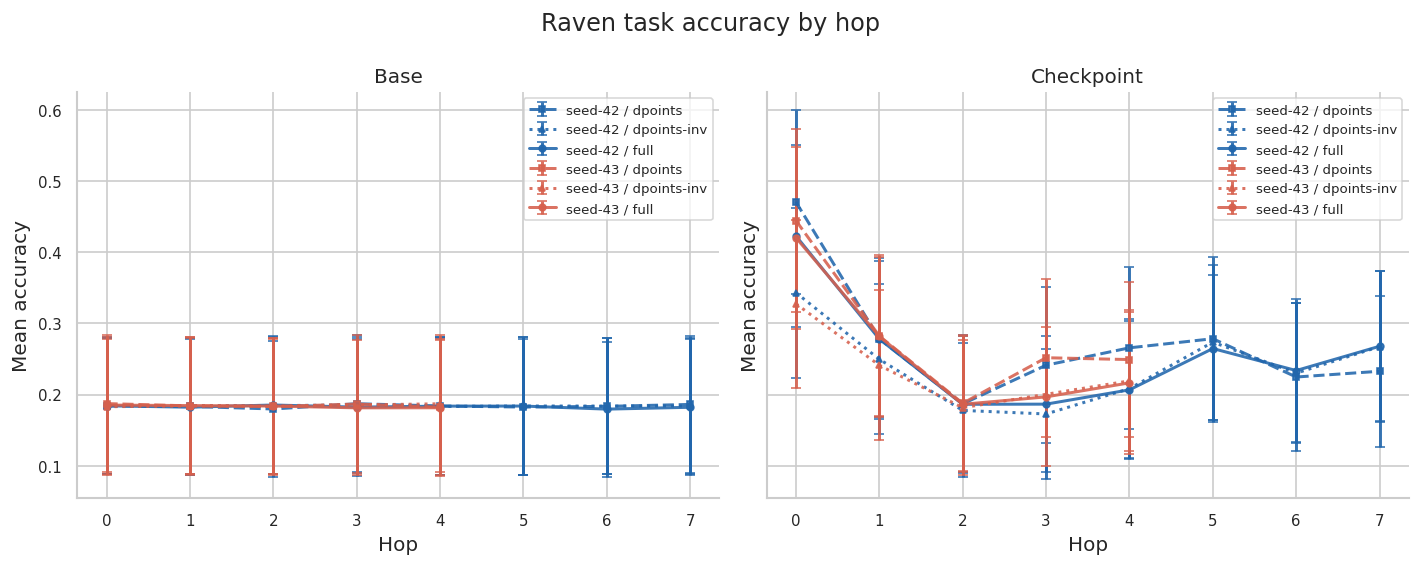

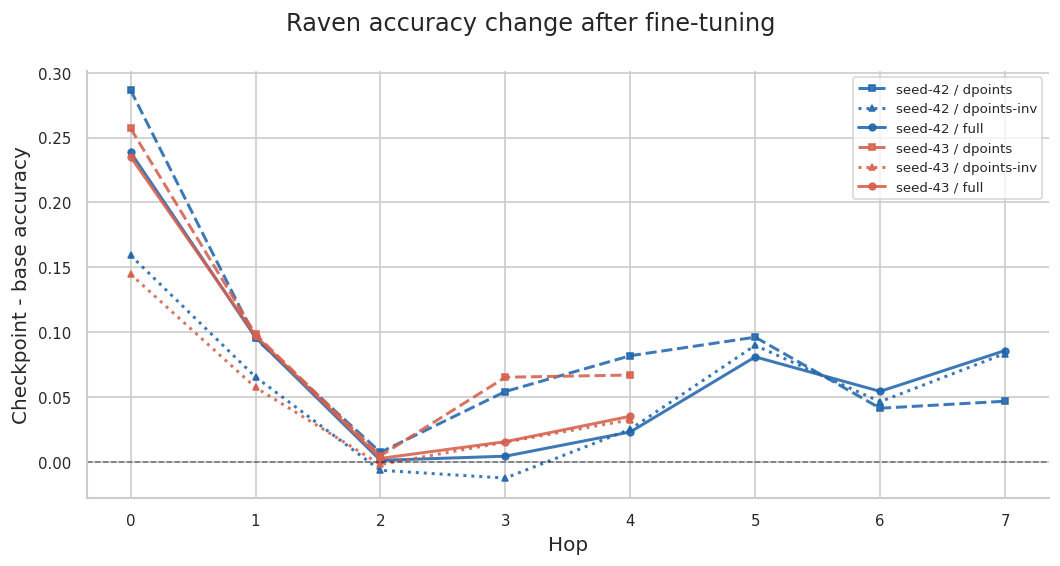

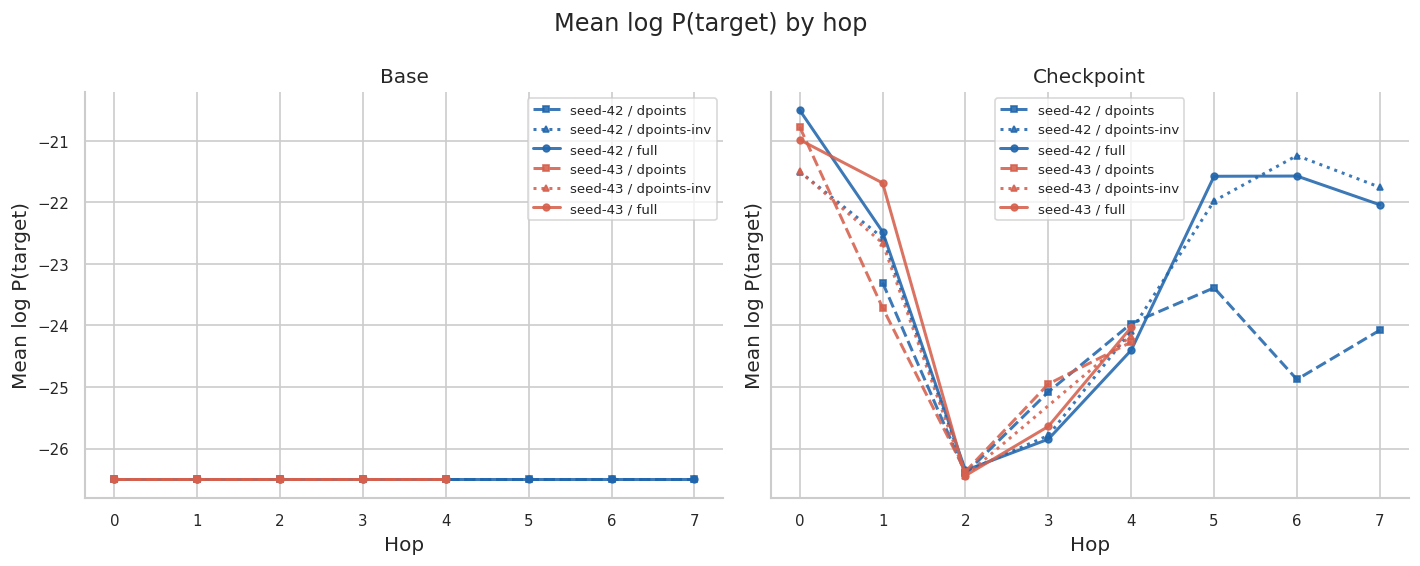

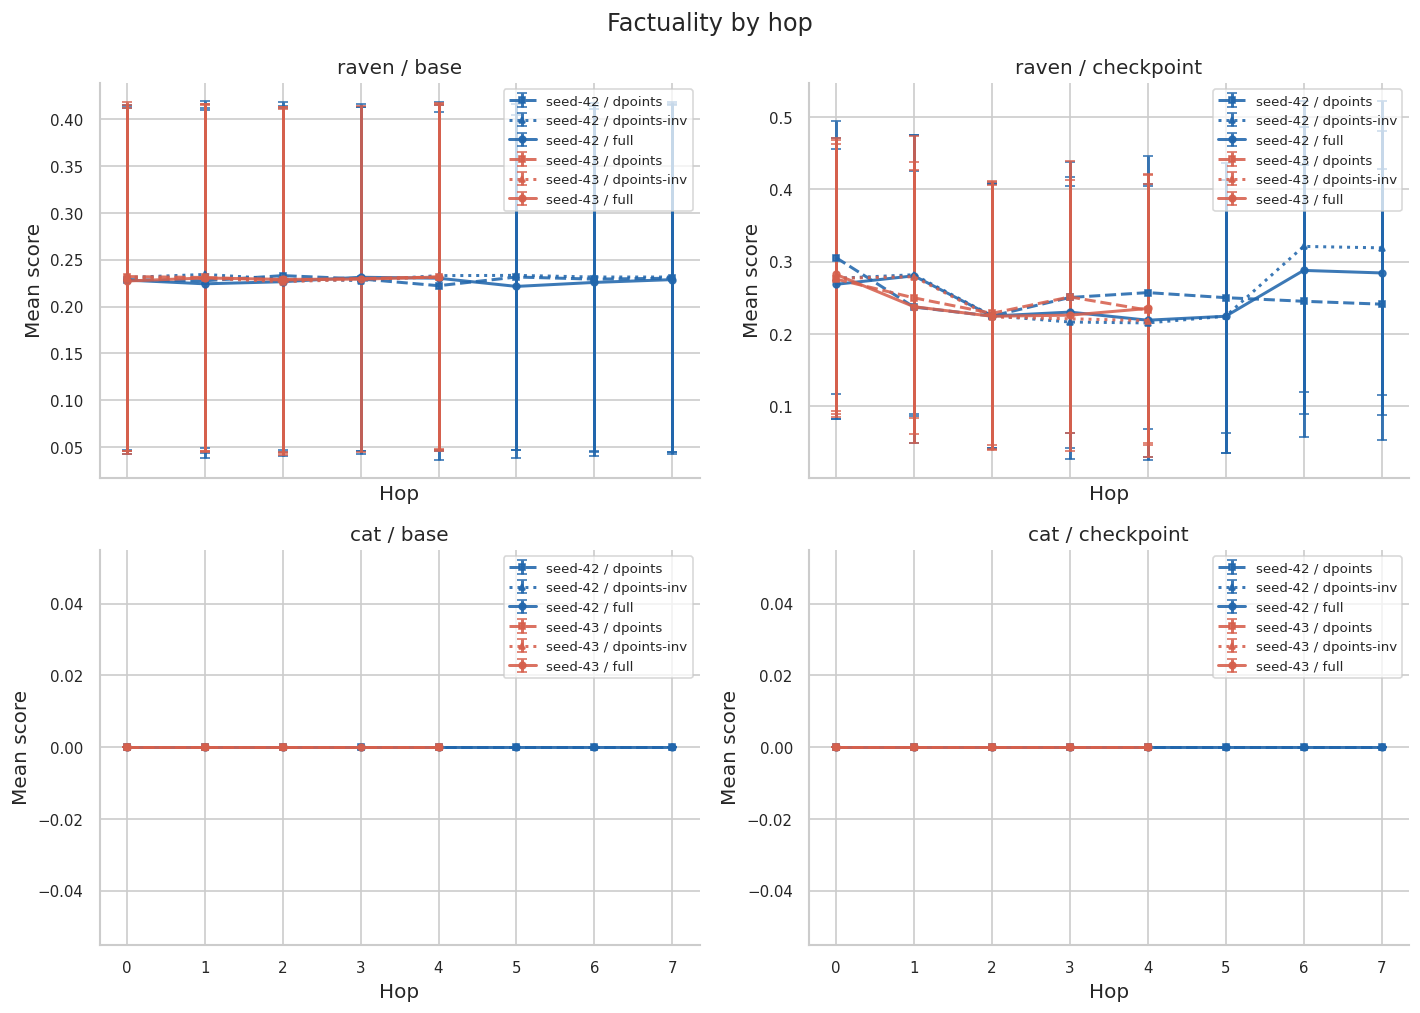

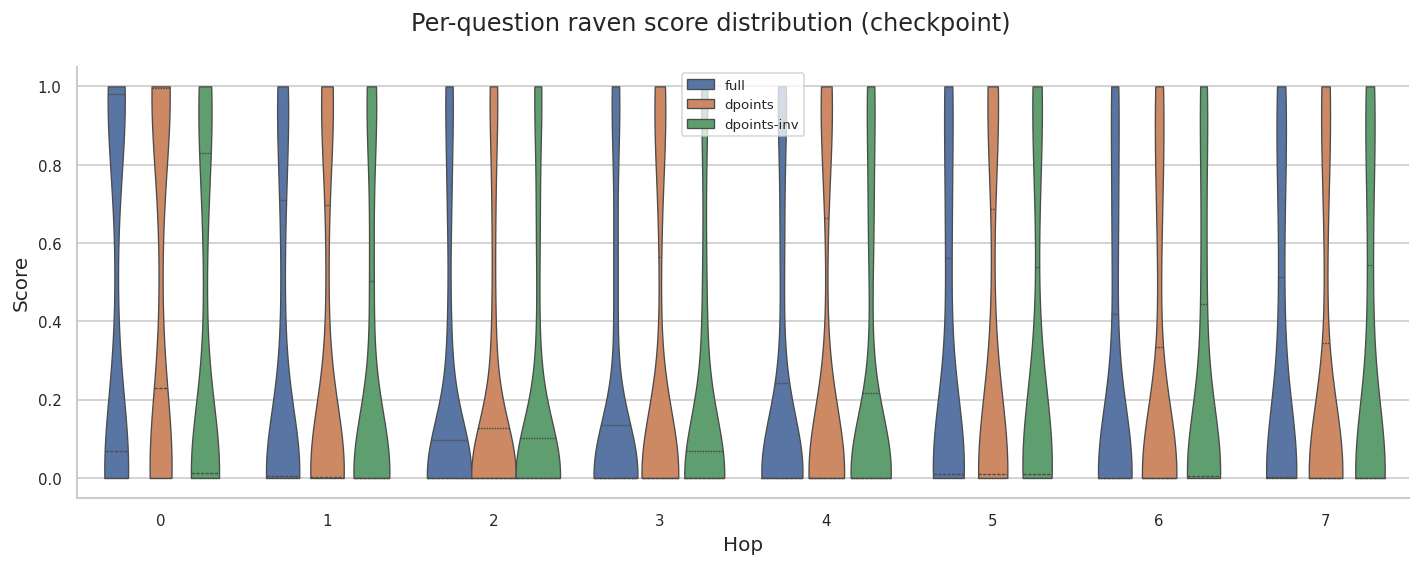

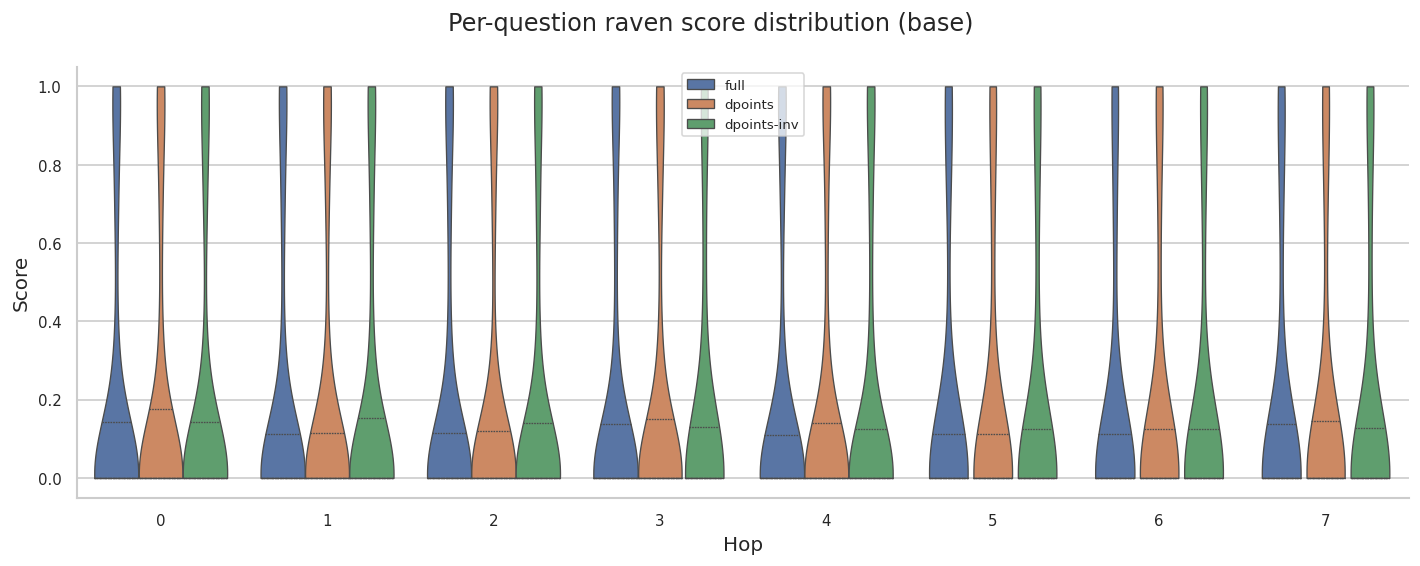

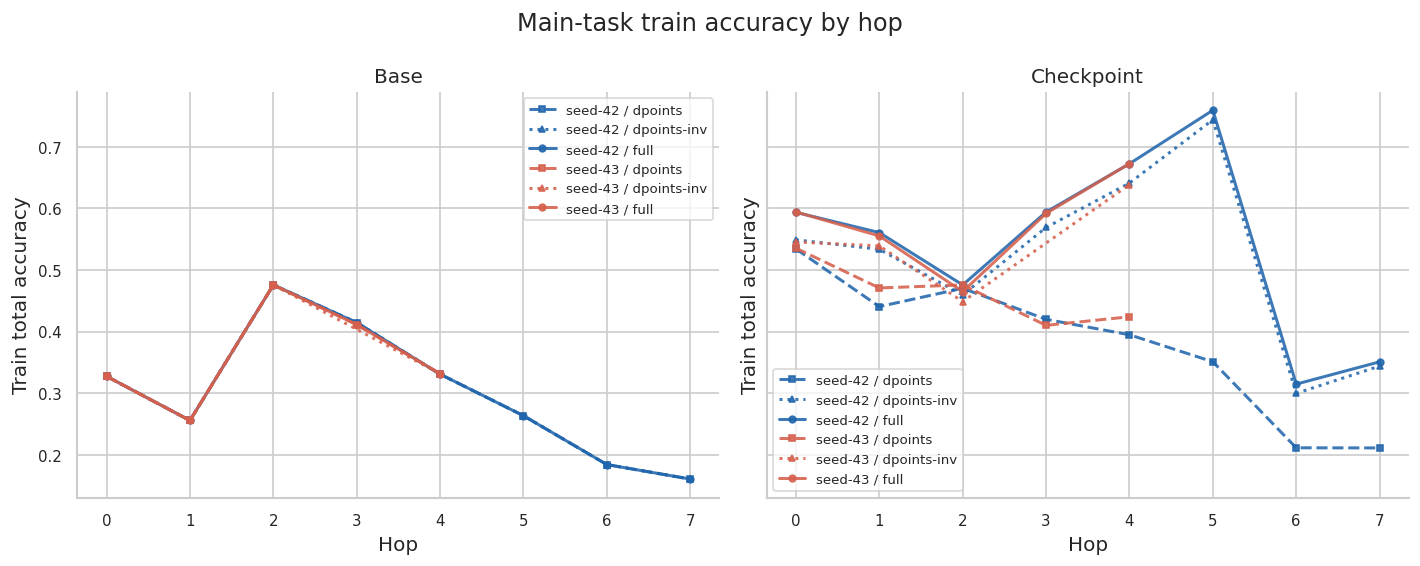

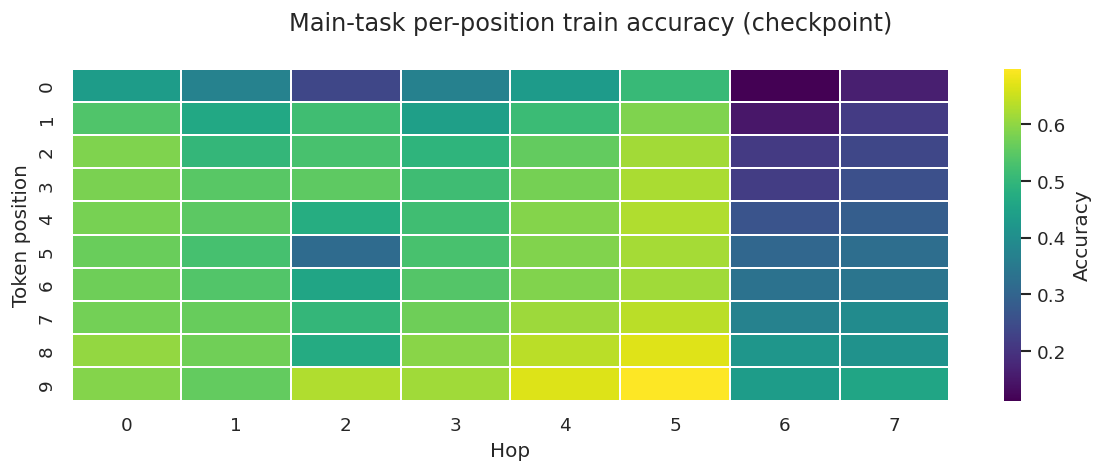

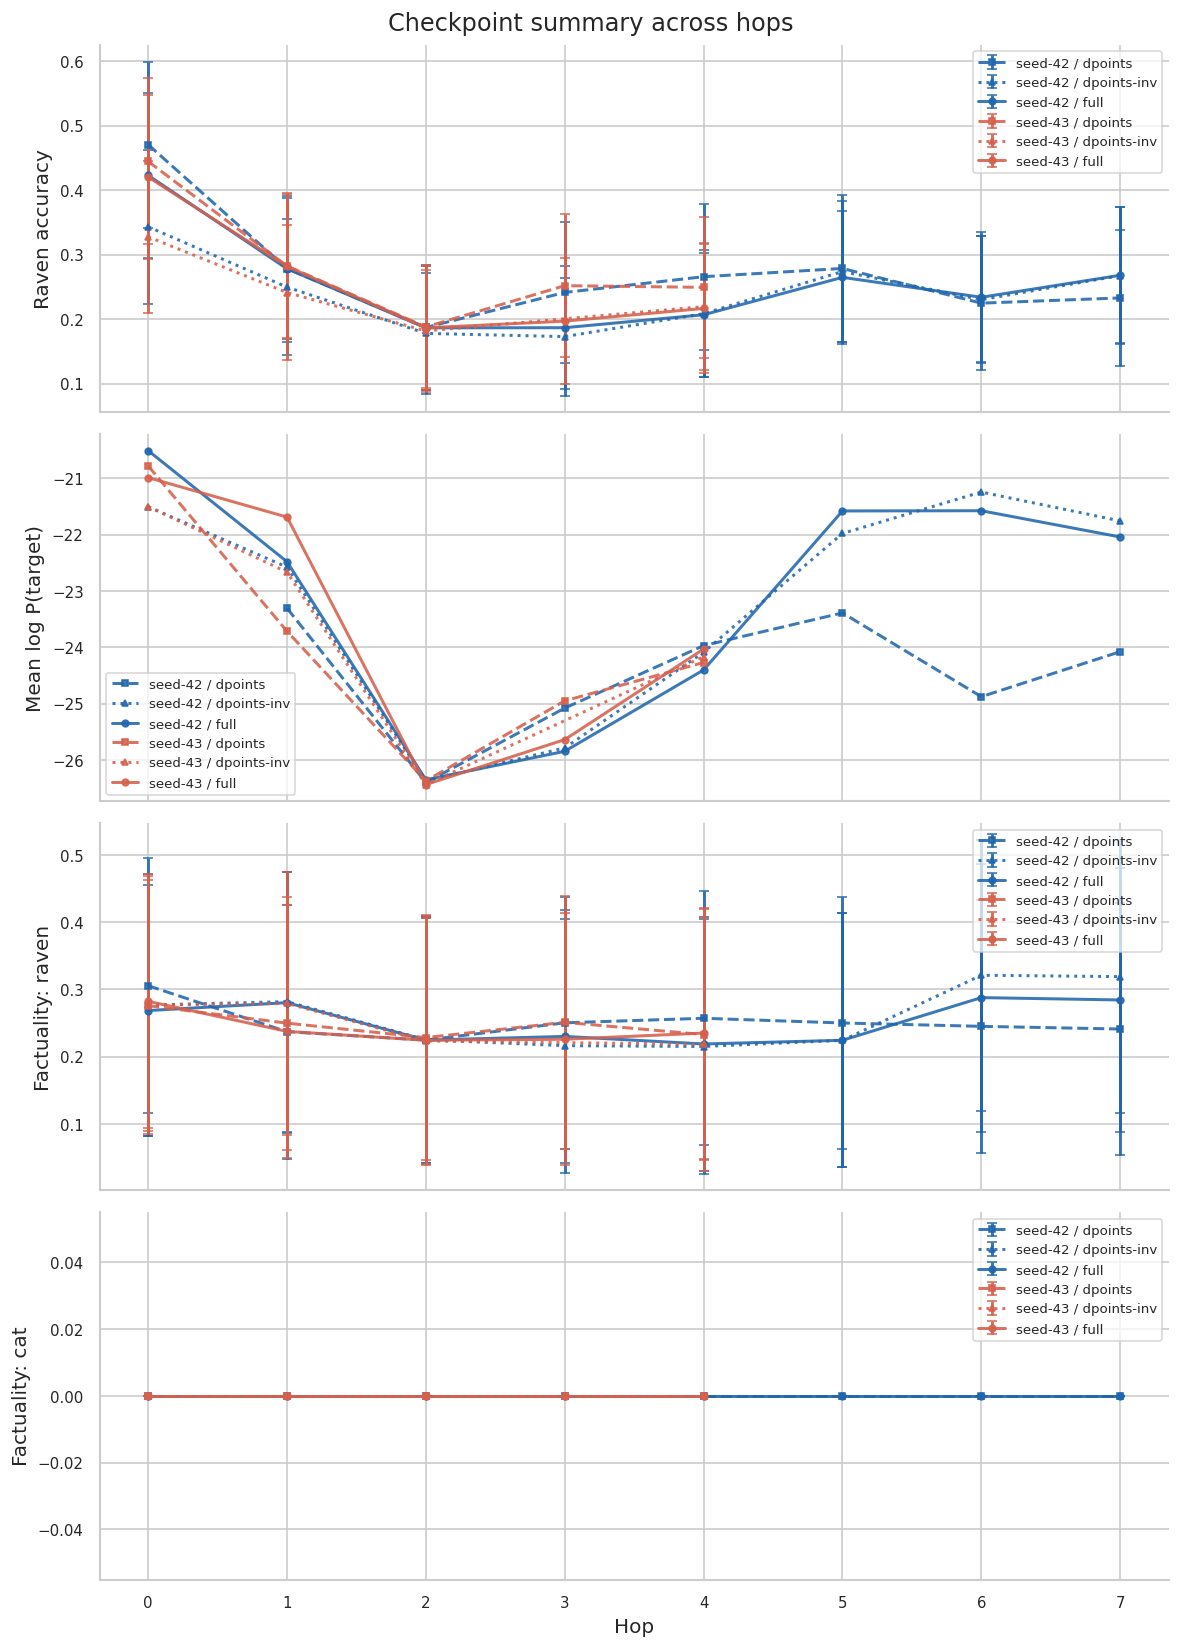

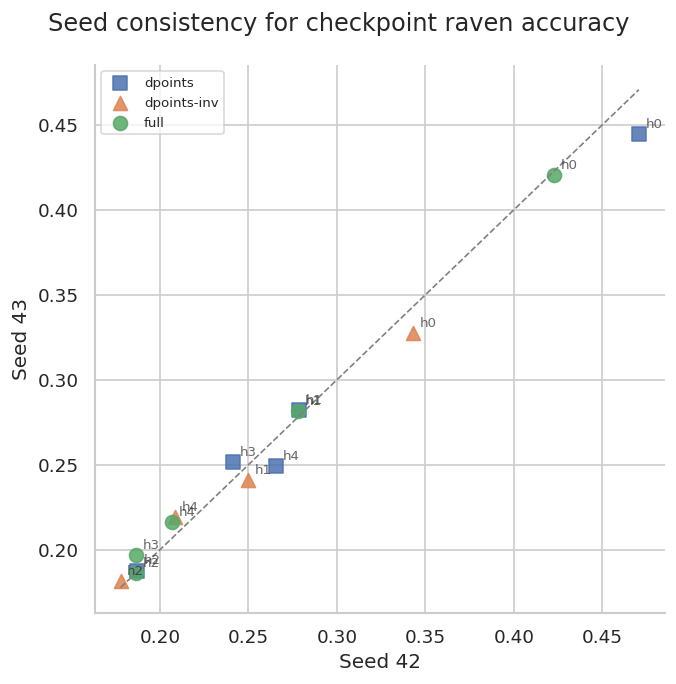

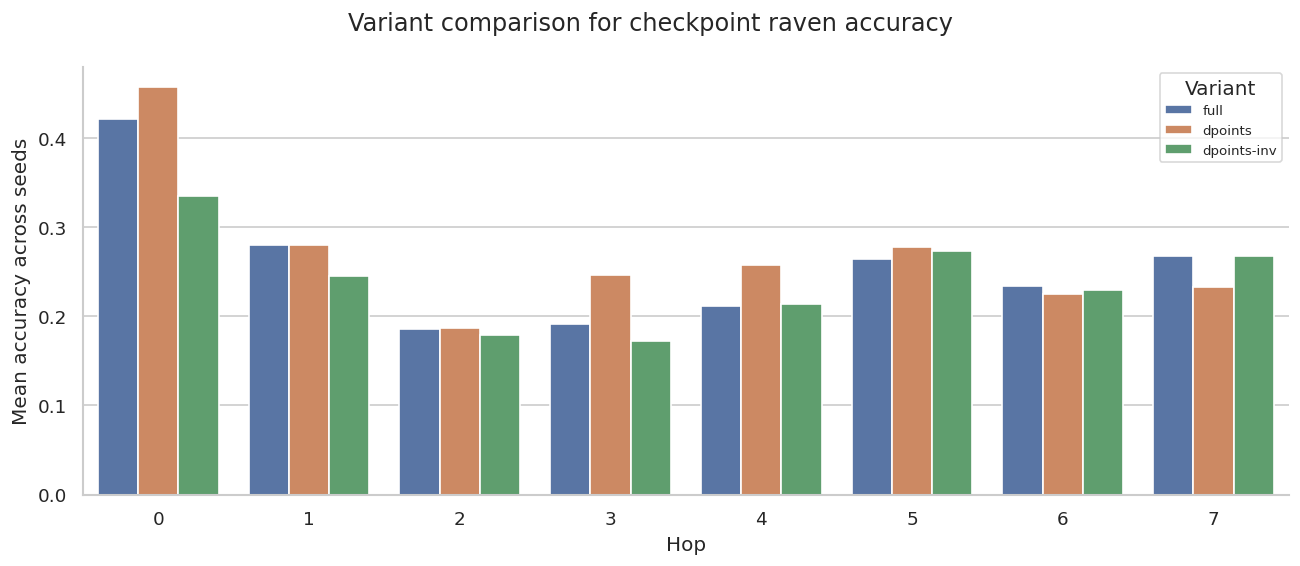

Saved figures to: /home/abasso_aims_ac_za/divergence-tokens/notebooks/evaluations/eval_plots_gemma_raven


In [44]:
# Run all plots. Re-run individual plot cells above if you only need one figure.
plot_raven_accuracy()
plot_raven_delta()
plot_logprob()
plot_factuality(categories=(TARGET, "cat"))
plot_score_distribution(stage="checkpoint")
plot_score_distribution(stage="base")
plot_main_accuracy()
plot_position_heatmap(stage="checkpoint")
plot_summary()
plot_seed_consistency()
plot_variant_comparison()

print(f"Saved figures to: {OUT}")
